## 3.2.1 Make Database

In [15]:
import math
import time
import numpy as np
import torch
from torch import nn
from torchvision import transforms
import matplotlib.pyplot as plt
import random

In [6]:
def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [8]:
true_w = torch.tensor([2.0, -3.0, 4.0])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [9]:
print('features:', features[0], '\nlabel:', labels[0])

features: tensor([ 2.2666, -0.6766, -0.1415]) 
label: tensor([10.1972])


<Figure size 350x250 with 0 Axes>

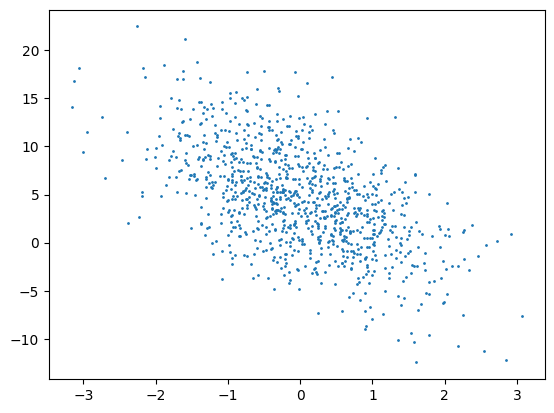

<Figure size 350x250 with 0 Axes>

In [12]:
plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1)
plt.figure(figsize = (3.5, 2.5))

## 3.2.2 Read Database

In [18]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)]
        )
        yield features[batch_indices], labels[batch_indices] 

In [19]:
batch_size = 10;

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 1.5127, -0.2599,  0.8895],
        [ 0.1648,  0.7462,  0.1941],
        [-0.9357, -0.3477, -0.5068],
        [-0.3160,  1.9808,  0.1189],
        [-0.3740,  0.1246,  2.1127],
        [ 0.1347,  2.0341, -0.9248],
        [-0.4477,  1.0143, -0.2898],
        [ 1.2877, -1.2984, -0.9618],
        [ 0.5843, -0.9058, -0.7143],
        [ 0.2762, -0.7968,  0.3094]]) 
 tensor([[11.5489],
        [ 3.0731],
        [ 1.3505],
        [-1.8972],
        [11.5329],
        [-5.3253],
        [-0.8972],
        [ 6.8003],
        [ 5.2355],
        [ 8.3791]])
